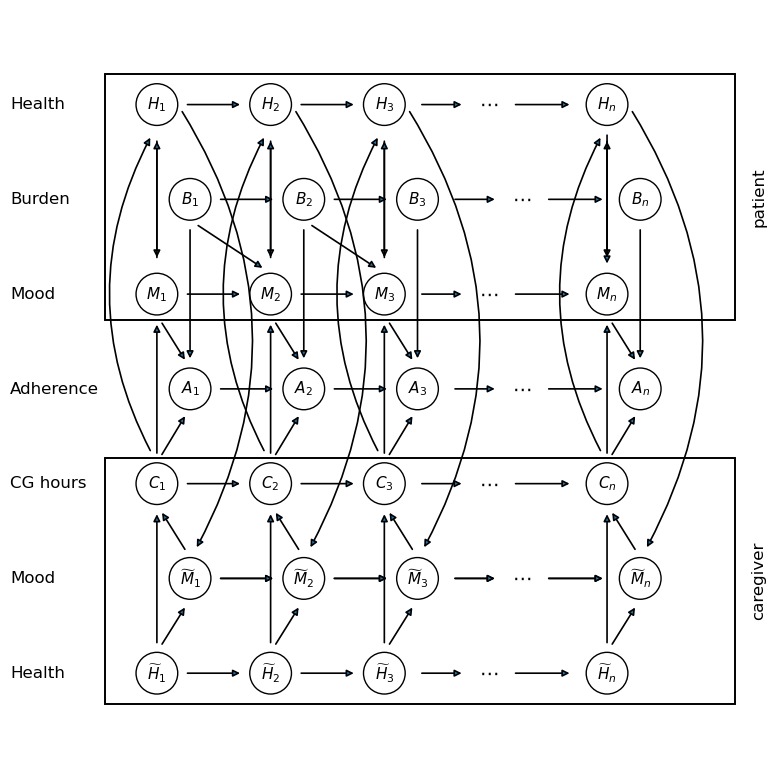

In [58]:
# Patient H_i (Health) -> Caregiver \widetilde{M}_i (Mood) with right-bending curved arrows.
# Full figure function including your previous content and the new right-bending arcs.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def draw_hbma_with_cg_hours_cg_mood_and_cg_habits(
    n=12,
    mood_dx=0.35,            # horizontal offset for PATIENT Habits / Mood / CG hours relative to Burden/Adherence
    node_radius=0.22,
    gap_after_third=1.2,     # gap between index 3 and the ellipsis
    gap_before_n=1.2,        # gap between ellipsis and index n
    figsize=(14.5, 9.2),
    savepath=None
):
    assert n >= 4, "Use n >= 4 to show 1,2,3,…,n."

    # --- Row y-coordinates (top to bottom) ---
    y_habits = 3.2      # PATIENT Health/Habits (aligned with x*_m)
    y_burden = 2.2      # PATIENT Burden (aligned with x*)
    y_mood   = 1.2      # PATIENT Mood   (aligned with x*_m)
    y_adh    = 0.2      # PATIENT Adherence (aligned with x*)
    y_cg     = -0.8     # CG hours (aligned with x*_m)
    y_cg_mood   = -1.8  # CG Mood  (aligned with x*)
    y_cg_habits = -2.8  # CG Health/Habits (aligned with x*_m), below CG Mood

    # --- Base x positions for indices 1, 2, 3, …, n (B/A aligned) ---
    x1, x2, x3 = 1.0, 2.2, 3.4
    x_ell = x3 + gap_after_third
    xn    = x_ell + gap_before_n

    # Staggered x for rows aligned with Mood/Habits
    x1m, x2m, x3m = x1 + mood_dx, x2 + mood_dx, x3 + mood_dx
    x_ellm        = x_ell + mood_dx
    xnm           = xn + mood_dx

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')

    # ---------- Helpers ----------
    def circle(x, y, label):
        c = plt.Circle((x, y), node_radius, fill=False)
        ax.add_patch(c)
        ax.text(x, y, label, ha='center', va='center', fontsize=11)

    def arrow(x0, y0, x1, y1, shorten_A=7, shorten_B=7, lw=1.2, dashed=False):
        props = dict(arrowstyle="-|>", shrinkA=shorten_A, shrinkB=shorten_B, lw=lw)
        if dashed:
            props["ls"] = (0, (4, 3))
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=props)

    def curved_arrow(x0, y0, x1, y1, rad=-0.25, shorten_A=7, shorten_B=7, lw=1.2):
        """
        Draw a curved arrow. rad>0
        shrinkA/shrinkB 
        """
        ax.annotate(
            "",
            xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=lw,
                shrinkA=shorten_A,
                shrinkB=shorten_B,
                connectionstyle=f"arc3,rad={rad}"
            ),
        )

    def double_arrow_vertical(x, y_top, y_bot, pad=0.02):
        # top -> bottom
        arrow(x, y_top - node_radius - pad, x, y_bot + node_radius + pad, shorten_A=10, shorten_B=10)
        # bottom -> top
        arrow(x, y_bot + node_radius + pad, x, y_top - node_radius - pad, shorten_A=10, shorten_B=10)

    # ---------- Nodes ----------
    # PATIENT Health/Habits
    circle(x1m, y_habits, r"$H_{1}$")
    circle(x2m, y_habits, r"$H_{2}$")
    circle(x3m, y_habits, r"$H_{3}$")
    ax.text(x_ellm, y_habits, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_habits, r"$H_{n}$")

    # PATIENT Burden
    circle(x1, y_burden, r"$B_{1}$")
    circle(x2, y_burden, r"$B_{2}$")
    circle(x3, y_burden, r"$B_{3}$")
    ax.text(x_ell, y_burden, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_burden, r"$B_{n}$")

    # PATIENT Mood
    circle(x1m, y_mood, r"$M_{1}$")
    circle(x2m, y_mood, r"$M_{2}$")
    circle(x3m, y_mood, r"$M_{3}$")
    ax.text(x_ellm, y_mood, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_mood, r"$M_{n}$")

    # PATIENT Adherence
    circle(x1, y_adh, r"$A_{1}$")
    circle(x2, y_adh, r"$A_{2}$")
    circle(x3, y_adh, r"$A_{3}$")
    ax.text(x_ell, y_adh, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_adh, r"$A_{n}$")

    # CG hours
    circle(x1m, y_cg, r"$C_{1}$")
    circle(x2m, y_cg, r"$C_{2}$")
    circle(x3m, y_cg, r"$C_{3}$")
    ax.text(x_ellm, y_cg, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_cg, r"$C_{n}$")

    # CG Mood
    circle(x1, y_cg_mood, r"$\widetilde{M}_{1}$")
    circle(x2, y_cg_mood, r"$\widetilde{M}_{2}$")
    circle(x3, y_cg_mood, r"$\widetilde{M}_{3}$")
    ax.text(x_ell, y_cg_mood, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_cg_mood, r"$\widetilde{M}_{n}$")

    # CG Health/Habits
    circle(x1m, y_cg_habits, r"$\widetilde{H}_{1}$")
    circle(x2m, y_cg_habits, r"$\widetilde{H}_{2}$")
    circle(x3m, y_cg_habits, r"$\widetilde{H}_{3}$")
    ax.text(x_ellm, y_cg_habits, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_cg_habits, r"$\widetilde{H}_{n}$")

    # ---------- Intra-row arrows ----------
    # Patient Health chain
    arrow(x1m + node_radius, y_habits, x2m - node_radius, y_habits)
    arrow(x2m + node_radius, y_habits, x3m - node_radius, y_habits)
    arrow(x3m + node_radius, y_habits, x_ellm - 0.05, y_habits, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_habits, xnm - node_radius, y_habits, shorten_A=16, shorten_B=12)

    # Burden chain
    arrow(x1 + node_radius, y_burden, x2 - node_radius, y_burden)
    arrow(x2 + node_radius, y_burden, x3 - node_radius, y_burden)
    arrow(x3 + node_radius, y_burden, x_ell - 0.05, y_burden, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_burden, xn - node_radius, y_burden, shorten_A=16, shorten_B=12)

    # Patient Mood chain
    arrow(x1m + node_radius, y_mood, x2m - node_radius, y_mood)
    arrow(x2m + node_radius, y_mood, x3m - node_radius, y_mood)
    arrow(x3m + node_radius, y_mood, x_ellm - 0.05, y_mood, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_mood, xnm - node_radius, y_mood, shorten_A=16, shorten_B=12)

    # Patient Adherence chain
    arrow(x1 + node_radius, y_adh, x2 - node_radius, y_adh)
    arrow(x2 + node_radius, y_adh, x3 - node_radius, y_adh)
    arrow(x3 + node_radius, y_adh, x_ell - 0.05, y_adh, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_adh, xn - node_radius, y_adh, shorten_A=16, shorten_B=12)

    # CG hours chain
    arrow(x1m + node_radius, y_cg, x2m - node_radius, y_cg)
    arrow(x2m + node_radius, y_cg, x3m - node_radius, y_cg)
    arrow(x3m + node_radius, y_cg, x_ellm - 0.05, y_cg, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_cg, xnm - node_radius, y_cg, shorten_A=16, shorten_B=12)

    # CG Mood chain
    arrow(x1 + node_radius, y_cg_mood, x2 - node_radius, y_cg_mood)
    arrow(x2 + node_radius, y_cg_mood, x3 - node_radius, y_cg_mood)
    arrow(x3 + node_radius, y_cg_mood, x_ell - 0.05, y_cg_mood, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_cg_mood, xn - node_radius, y_cg_mood, shorten_A=16, shorten_B=12)

    # CG Health chain
    arrow(x1m + node_radius, y_cg_habits, x2m - node_radius, y_cg_habits)
    arrow(x2m + node_radius, y_cg_habits, x3m - node_radius, y_cg_habits)
    arrow(x3m + node_radius, y_cg_habits, x_ellm - 0.05, y_cg_habits, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_cg_habits, xnm - node_radius, y_cg_habits, shorten_A=16, shorten_B=12)

    # ---------- Cross-row arrows (Patient block) ----------
    # H_i <-> M_i (patient)
    double_arrow_vertical(x1m, y_habits, y_mood, pad=0.02)
    double_arrow_vertical(x2m, y_habits, y_mood, pad=0.02)
    double_arrow_vertical(x3m, y_habits, y_mood, pad=0.02)
    double_arrow_vertical(xnm,  y_habits, y_mood, pad=0.02)

    # C_i -> H_i (left-bending), influence of CG hours on patient habits
    for xm in (x1m, x2m, x3m, xnm):
        curved_arrow(xm, y_cg + node_radius, xm, y_habits - node_radius,
                     rad=-0.28, shorten_A=10, shorten_B=10)

    # B_i -> M_{i+1} (patient)
    arrow(x1, y_burden - node_radius, x2m, y_mood + node_radius)
    arrow(x2, y_burden - node_radius, x3m, y_mood + node_radius)

    # B_i -> A_i and M_i -> A_i (patient), i=1,2,3
    for xb, xm, xa in [(x1, x1m, x1), (x2, x2m, x2), (x3, x3m, x3)]:
        arrow(xb, y_burden - node_radius, xa, y_adh + node_radius)
        arrow(xm, y_mood   - node_radius, xa, y_adh + node_radius)

    # At index n (patient)
    arrow(xnm, y_habits - node_radius, xnm, y_mood + node_radius)  # H_n -> M_n
    arrow(xnm, y_mood   - node_radius, xn,  y_adh  + node_radius)  # M_n -> A_n
    arrow(xn,  y_burden - node_radius, xn,  y_adh  + node_radius)  # B_n -> A_n

    # CG hours -> patient Mood / Adherence
    for xc, xm, xa in [(x1m, x1m, x1), (x2m, x2m, x2), (x3m, x3m, x3), (xnm, xnm, xn)]:
        arrow(xc, y_cg + node_radius, xm, y_mood - node_radius)
        arrow(xc, y_cg + node_radius, xa, y_adh  - node_radius + 0.02)

    # Caregiver Mood progression and links to CG hours
    arrow(x1 + node_radius, y_cg_mood, x2 - node_radius, y_cg_mood)
    arrow(x1,               y_cg_mood + node_radius, x1m, y_cg - node_radius)

    arrow(x2 + node_radius, y_cg_mood, x3 - node_radius, y_cg_mood)
    arrow(x2,               y_cg_mood + node_radius, x2m, y_cg - node_radius)

    arrow(x3 + node_radius, y_cg_mood, x_ell - 0.05, y_cg_mood, shorten_A=12, shorten_B=16)
    arrow(x3,               y_cg_mood + node_radius, x3m, y_cg - node_radius)

    arrow(x_ell + 0.05, y_cg_mood, xn - node_radius, y_cg_mood, shorten_A=16, shorten_B=12)
    arrow(xn,            y_cg_mood + node_radius, xnm, y_cg - node_radius)

    # CG Health -> CG Mood, CG Health -> CG hours
    for (xh_m, xmood, xcg_) in [(x1m, x1,  x1m), (x2m, x2, x2m), (x3m, x3, x3m), (xnm, xn, xnm)]:
        arrow(xh_m, y_cg_habits + node_radius, xmood, y_cg_mood - node_radius)
        arrow(xh_m, y_cg_habits + node_radius, xcg_,  y_cg      - node_radius)

    # ========== NEW: Patient H_i (right side) -> Caregiver \widetilde{M}_i with RIGHT-bending curved arrows ==========
    small_pad = 0.02

    # Patient H_i (right side) -> Caregiver \widetilde{M}_i, aim at TOP-center of mood circles
    curved_arrow(x1m + node_radius, y_habits,
             x1, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    curved_arrow(x2m + node_radius, y_habits,
             x2, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    curved_arrow(x3m + node_radius, y_habits,
             x3, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    curved_arrow(xnm + node_radius, y_habits,
             xn, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    # ---------- Patient bounding box ----------
    left   = (x1 - 1.05) + 0.15
    right  = xn + 1.0
    top    = y_habits + node_radius + 0.1
    bottom = y_adh    - node_radius + 0.95
    rect_patient = Rectangle((left, bottom), width=right - left, height=top - bottom,
                             fill=False, linewidth=1.4)
    ax.add_patch(rect_patient)

    # Labels inside patient box
    label_x = left - 1
    ax.text(label_x, y_habits,  "Health",    ha='left', va='center', fontsize=12)
    ax.text(label_x, y_burden,  "Burden",    ha='left', va='center', fontsize=12)
    ax.text(label_x, y_mood,    "Mood",      ha='left', va='center', fontsize=12)
    ax.text(label_x, y_adh,     "Adherence", ha='left', va='center', fontsize=12)

    # "patient" label
    ax.text(right + 0.25, (top + bottom)/2.0, "patient", rotation=90,
            ha='center', va='center', fontsize=12)

    # ---------- Caregiver bounding box ----------
    left2   = left
    right2  = right
    top2    = y_cg_mood   + node_radius + 1.05
    bottom2 = y_cg_habits - node_radius - 0.1
    rect_cg = Rectangle((left2, bottom2), width=right2 - left2, height=top2 - bottom2,
                        fill=False, linewidth=1.4)
    ax.add_patch(rect_cg)

    # Caregiver labels
    label_x2 = left2 - 1
    ax.text(label_x2, y_cg_mood,   "Mood",     ha='left', va='center', fontsize=12)
    ax.text(label_x2, y_cg,        "CG hours", ha='left', va='center', fontsize=12)
    ax.text(label_x2, y_cg_habits, "Health",   ha='left', va='center', fontsize=12)

    # "caregiver" label
    ax.text(right2 + 0.25, (top2 + bottom2)/2.0, "caregiver", rotation=90,
            ha='center', va='center', fontsize=12)

    # ---------- Axis cosmetics ----------
    ax.set_xlim((x1 - 1.05) - 0.2, xn + 1.4)
    ax.set_ylim(y_cg_habits - 0.8, y_habits + 1.0)
    ax.axis('off')

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=230)
    plt.show()


# Example
draw_hbma_with_cg_hours_cg_mood_and_cg_habits(
    n=12,
    mood_dx=-0.35,
    node_radius=0.22,
    gap_after_third=1.1,
    gap_before_n=1.25,
    figsize=(15.0, 9.6)
)


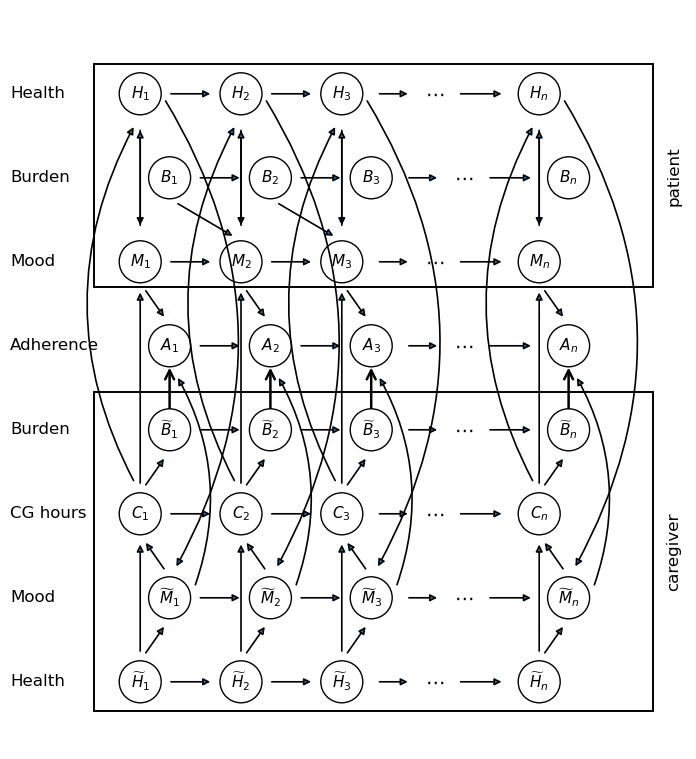

In [16]:
# Caregiver Adherence DAG variant per your specs:
# 1) Remove patient Burden -> patient Adherence arrows.
# 2) Add a caregiver Burden row (aligned with Adherence/Burden x-grid) above CG hours:
#    - \widetilde{B}_1 -> \widetilde{B}_2 -> \widetilde{B}_3 -> ... -> \widetilde{B}_n
#    - \widetilde{B}_i -> A_i  (each caregiver Burden to corresponding Adherence)
# 3) Remove CG hours -> Adherence arrows.
# 4) From each caregiver Mood node, draw a right-bending curved arrow to its corresponding Adherence node.
# 5) (This edit) From each CG hours node C_i, draw a straight arrow to the corresponding caregiver Burden node \widetilde{B}_i.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def draw_caregiver_adherence_dag(
    n=12,
    mood_dx=0.35,            # horizontal offset for rows aligned with Mood/Habits vs Burden/Adherence
    node_radius=0.5,
    gap_after_third=1.2,     # gap between index 3 and the ellipsis
    gap_before_n=1.2,        # gap between ellipsis and index n
    figsize=(15.0, 9.6),
    savepath=None
):
    assert n >= 4, "Use n >= 4 to show 1,2,3,…,n."

    # --- Row y-coordinates (top to bottom) ---
    y_habits     = 3.2    # PATIENT Health/Habits (aligned with x*_m)
    y_burden     = 2.2    # PATIENT Burden (aligned with x*)
    y_mood       = 1.2    # PATIENT Mood   (aligned with x*_m)
    y_adh        = 0.2    # PATIENT Adherence (aligned with x*)
    y_cg_burden  = -0.8   # CAREGIVER Burden (aligned with x*), above CG hours
    y_cg_hours   = -1.8   # CG hours (aligned with x*_m)
    y_cg_mood    = -2.8   # CAREGIVER Mood  (aligned with x*)
    y_cg_habits  = -3.8   # CAREGIVER Health/Habits (aligned with x*_m)

    # --- Base x positions for indices 1, 2, 3, …, n (B/A aligned) ---
    x1, x2, x3 = 1.0, 2.2, 3.4
    x_ell = x3 + gap_after_third
    xn    = x_ell + gap_before_n

    # Staggered x for rows aligned with Mood/Habits/CG-hours/CG-habits
    x1m, x2m, x3m = x1 + mood_dx, x2 + mood_dx, x3 + mood_dx
    x_ellm        = x_ell + mood_dx
    xnm           = xn + mood_dx

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')

    # ---------- Helpers ----------
    def circle(x, y, label):
        c = plt.Circle((x, y), node_radius, fill=False)
        ax.add_patch(c)
        ax.text(x, y, label, ha='center', va='center', fontsize=11)

    def arrow(x0, y0, x1, y1, shorten_A=7, shorten_B=7, lw=1.2, dashed=False):
        """Straight arrow with optional dash pattern."""
        props = dict(arrowstyle="-|>", shrinkA=shorten_A, shrinkB=shorten_B, lw=lw)
        if dashed:
            props["ls"] = (0, (4, 3))
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=props)

    def curved_arrow(x0, y0, x1, y1, rad=-0.25, shorten_A=7, shorten_B=7, lw=1.2):
        """
        Curved arrow using arc3 connectionstyle.
        - rad < 0 bends to the RIGHT in this left-to-right layout.
        - rad > 0 bends to the LEFT.
        """
        ax.annotate(
            "",
            xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=lw,
                shrinkA=shorten_A,
                shrinkB=shorten_B,
                connectionstyle=f"arc3,rad={rad}"
            ),
        )

    def double_arrow_vertical(x, y_top, y_bot, pad=0.02):
        """Two opposite vertical arrows between same-column nodes."""
        # top -> bottom
        arrow(x, y_top - node_radius - pad, x, y_bot + node_radius + pad, shorten_A=10, shorten_B=10)
        # bottom -> top
        arrow(x, y_bot + node_radius + pad, x, y_top - node_radius - pad, shorten_A=10, shorten_B=10)

    # ---------- Nodes ----------
    # PATIENT Health/Habits (H)
    circle(x1m, y_habits, r"$H_{1}$")
    circle(x2m, y_habits, r"$H_{2}$")
    circle(x3m, y_habits, r"$H_{3}$")
    ax.text(x_ellm, y_habits, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_habits, r"$H_{n}$")

    # PATIENT Burden (B)
    circle(x1, y_burden, r"$B_{1}$")
    circle(x2, y_burden, r"$B_{2}$")
    circle(x3, y_burden, r"$B_{3}$")
    ax.text(x_ell, y_burden, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_burden, r"$B_{n}$")

    # PATIENT Mood (M)
    circle(x1m, y_mood, r"$M_{1}$")
    circle(x2m, y_mood, r"$M_{2}$")
    circle(x3m, y_mood, r"$M_{3}$")
    ax.text(x_ellm, y_mood, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_mood, r"$M_{n}$")

    # PATIENT Adherence (A)
    circle(x1, y_adh, r"$A_{1}$")
    circle(x2, y_adh, r"$A_{2}$")
    circle(x3, y_adh, r"$A_{3}$")
    ax.text(x_ell, y_adh, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_adh, r"$A_{n}$")

    # CAREGIVER Burden (\widetilde{B}), aligned with x* (same grid as A/B)
    circle(x1, y_cg_burden, r"$\widetilde{B}_{1}$")
    circle(x2, y_cg_burden, r"$\widetilde{B}_{2}$")
    circle(x3, y_cg_burden, r"$\widetilde{B}_{3}$")
    ax.text(x_ell, y_cg_burden, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_cg_burden, r"$\widetilde{B}_{n}$")

    # CG hours (C), aligned with x*_m
    circle(x1m, y_cg_hours, r"$C_{1}$")
    circle(x2m, y_cg_hours, r"$C_{2}$")
    circle(x3m, y_cg_hours, r"$C_{3}$")
    ax.text(x_ellm, y_cg_hours, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_cg_hours, r"$C_{n}$")

    # CAREGIVER Mood (\widetilde{M}), aligned with x*
    circle(x1, y_cg_mood, r"$\widetilde{M}_{1}$")
    circle(x2, y_cg_mood, r"$\widetilde{M}_{2}$")
    circle(x3, y_cg_mood, r"$\widetilde{M}_{3}$")
    ax.text(x_ell, y_cg_mood, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xn, y_cg_mood, r"$\widetilde{M}_{n}$")

    # CAREGIVER Health/Habits (\widetilde{H}), aligned with x*_m
    circle(x1m, y_cg_habits, r"$\widetilde{H}_{1}$")
    circle(x2m, y_cg_habits, r"$\widetilde{H}_{2}$")
    circle(x3m, y_cg_habits, r"$\widetilde{H}_{3}$")
    ax.text(x_ellm, y_cg_habits, r"$\cdots$", ha='center', va='center', fontsize=14)
    circle(xnm, y_cg_habits, r"$\widetilde{H}_{n}$")

    # ---------- Intra-row chains ----------
    # Patient Health chain
    arrow(x1m + node_radius, y_habits, x2m - node_radius, y_habits)
    arrow(x2m + node_radius, y_habits, x3m - node_radius, y_habits)
    arrow(x3m + node_radius, y_habits, x_ellm - 0.05, y_habits, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_habits, xnm - node_radius, y_habits, shorten_A=16, shorten_B=12)

    # Patient Burden chain
    arrow(x1 + node_radius, y_burden, x2 - node_radius, y_burden)
    arrow(x2 + node_radius, y_burden, x3 - node_radius, y_burden)
    arrow(x3 + node_radius, y_burden, x_ell - 0.05, y_burden, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_burden, xn - node_radius, y_burden, shorten_A=16, shorten_B=12)

    # Patient Mood chain
    arrow(x1m + node_radius, y_mood, x2m - node_radius, y_mood)
    arrow(x2m + node_radius, y_mood, x3m - node_radius, y_mood)
    arrow(x3m + node_radius, y_mood, x_ellm - 0.05, y_mood, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_mood, xnm - node_radius, y_mood, shorten_A=16, shorten_B=12)

    # Patient Adherence chain (optional)
    arrow(x1 + node_radius, y_adh, x2 - node_radius, y_adh)
    arrow(x2 + node_radius, y_adh, x3 - node_radius, y_adh)
    arrow(x3 + node_radius, y_adh, x_ell - 0.05, y_adh, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_adh, xn - node_radius, y_adh, shorten_A=16, shorten_B=12)

    # CAREGIVER Burden chain
    arrow(x1 + node_radius, y_cg_burden, x2 - node_radius, y_cg_burden)
    arrow(x2 + node_radius, y_cg_burden, x3 - node_radius, y_cg_burden)
    arrow(x3 + node_radius, y_cg_burden, x_ell - 0.05, y_cg_burden, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_cg_burden, xn - node_radius, y_cg_burden, shorten_A=16, shorten_B=12)

    # CG hours chain
    arrow(x1m + node_radius, y_cg_hours, x2m - node_radius, y_cg_hours)
    arrow(x2m + node_radius, y_cg_hours, x3m - node_radius, y_cg_hours)
    arrow(x3m + node_radius, y_cg_hours, x_ellm - 0.05, y_cg_hours, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_cg_hours, xnm - node_radius, y_cg_hours, shorten_A=16, shorten_B=12)

    # CAREGIVER Mood chain
    arrow(x1 + node_radius, y_cg_mood, x2 - node_radius, y_cg_mood)
    arrow(x2 + node_radius, y_cg_mood, x3 - node_radius, y_cg_mood)
    arrow(x3 + node_radius, y_cg_mood, x_ell - 0.05, y_cg_mood, shorten_A=12, shorten_B=16)
    arrow(x_ell + 0.05, y_cg_mood, xn - node_radius, y_cg_mood, shorten_A=16, shorten_B=12)

    # CAREGIVER Health chain
    arrow(x1m + node_radius, y_cg_habits, x2m - node_radius, y_cg_habits)
    arrow(x2m + node_radius, y_cg_habits, x3m - node_radius, y_cg_habits)
    arrow(x3m + node_radius, y_cg_habits, x_ellm - 0.05, y_cg_habits, shorten_A=12, shorten_B=16)
    arrow(x_ellm + 0.05, y_cg_habits, xnm - node_radius, y_cg_habits, shorten_A=16, shorten_B=12)

    # ---------- Cross-row arrows (Patient block) ----------
    # Patient H_i <-> M_i (bidirectional)
    double_arrow_vertical(x1m, y_habits, y_mood, pad=0.02)
    double_arrow_vertical(x2m, y_habits, y_mood, pad=0.02)
    double_arrow_vertical(x3m, y_habits, y_mood, pad=0.02)
    double_arrow_vertical(xnm,  y_habits, y_mood, pad=0.02)

    # Influence of CG hours on patient Habits (curved, left-bending)
    for xm in (x1m, x2m, x3m, xnm):
        curved_arrow(xm, y_cg_hours + node_radius, xm, y_habits - node_radius,
                     rad=-0.28, shorten_A=10, shorten_B=10)

    # Patient Burden -> next Patient Mood
    arrow(x1, y_burden - node_radius, x2m, y_mood + node_radius)
    arrow(x2, y_burden - node_radius, x3m, y_mood + node_radius)

    # IMPORTANT CHANGE (1): Remove ALL patient Burden -> patient Adherence arrows
    # (So we DO NOT draw B_i -> A_i anywhere, including index n.)

    # Patient M_i -> A_i for i=1,2,3 and index n
    for xm, xa in [(x1m, x1), (x2m, x2), (x3m, x3)]:
        arrow(xm, y_mood - node_radius, xa, y_adh + node_radius)
    arrow(xnm, y_mood - node_radius, xn, y_adh + node_radius)  # M_n -> A_n

   # ---------- Cross-row arrows (Caregiver block) ----------
    # Caregiver Burden -> Adherence (UPWARD), with long, visible shafts
    # Start at ABOVE-OUTSIDE center of \widetilde{B}_i; end at BELOW-OUTSIDE center of A_i.

    outer_pad = 0.12   # distance outside the circle edge for both ends
    extra_len = 0.28   # add length to the shaft (increase for longer arrows)

    def long_up_arrow_from_B_to_A(xb):
        # nominal (outside) anchors
        y_tail0 = y_cg_burden + node_radius + outer_pad   # just above \widetilde{B}
        y_head0 = y_adh       - node_radius - outer_pad   # just below A

        # Try to lengthen the shaft without entering circles:
        #   - pull tail DOWN a bit  (but keep it >= just-above-B)
        #   - push head UP a bit    (but keep it <= just-below-A)
        # Compute maximum safe extension based on current gap
        gap = y_head0 - y_tail0
        safe_extend = max(0.0, gap/2 - 0.02)   # keep a safety margin to stay outside rings
        ext = min(extra_len, safe_extend)

        y_tail = y_tail0 - ext      # move tail downward (makes the shaft longer)
        y_head = y_head0 + ext      # move head upward  (still below A circle)

        ax.annotate(
            "",
            xy=(xb, y_head),             # arrow head (toward Adherence, above)
            xytext=(xb, y_tail),         # arrow tail (from Caregiver Burden, below)
            arrowprops=dict(
                arrowstyle="->",         # clean shaft and head
                lw=1.8,                  # thicker shaft
                mutation_scale=16,       # larger arrowhead
                shrinkA=0, shrinkB=0,    # don't shrink the shaft
            ),
            zorder=5, clip_on=False
        )

    for xb in (x1, x2, x3, xn):
        long_up_arrow_from_B_to_A(xb)



    # (This edit) CG hours -> CG Burden (C_i -> \widetilde{B}_i), i = 1,2,3,n
    # Correct vertical coordinates: from y_cg_hours (source) to y_cg_burden (target).
    for (xc, xb) in [(x1m, x1), (x2m, x2), (x3m, x3), (xnm, xn)]:
        arrow(xc, y_cg_hours + node_radius, xb, y_cg_burden - node_radius)

    # CG hours -> patient Mood (keep), but (3) remove CG hours -> Adherence
    for xc, xm in [(x1m, x1m), (x2m, x2m), (x3m, x3m), (xnm, xnm)]:
        arrow(xc, y_cg_hours + node_radius, xm, y_mood - node_radius)
        # DO NOT draw: arrow(xc, y_cg_hours + node_radius, xa, y_adh - node_radius)
    
    # ========== NEW: Patient H_i (right side) -> Caregiver \widetilde{M}_i with RIGHT-bending curved arrows ==========
    small_pad = 0.02

    # Patient H_i (right side) -> Caregiver \widetilde{M}_i, aim at TOP-center of mood circles
    curved_arrow(x1m + node_radius, y_habits,
             x1, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    curved_arrow(x2m + node_radius, y_habits,
             x2, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    curved_arrow(x3m + node_radius, y_habits,
             x3, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    curved_arrow(xnm + node_radius, y_habits,
             xn, y_cg_mood + node_radius - small_pad,
             rad=-0.30, shorten_A=6, shorten_B=10, lw=1.2)

    # Caregiver Mood -> CG hours (keep existing)
    arrow(x1, y_cg_mood + node_radius, x1m, y_cg_hours - node_radius)
    arrow(x2, y_cg_mood + node_radius, x2m, y_cg_hours - node_radius)
    arrow(x3, y_cg_mood + node_radius, x3m, y_cg_hours - node_radius)
    arrow(xn, y_cg_mood + node_radius, xnm, y_cg_hours - node_radius)

    # Caregiver Health -> Caregiver Mood & -> CG hours (keep existing)
    for (xh_m, xmood, xcg_) in [(x1m, x1,  x1m), (x2m, x2, x2m), (x3m, x3, x3m), (xnm, xn, xnm)]:
        arrow(xh_m, y_cg_habits + node_radius, xmood, y_cg_mood - node_radius)
        arrow(xh_m, y_cg_habits + node_radius, xcg_,  y_cg_hours - node_radius)

    # (4) Caregiver Mood (right-bending) -> Adherence (aim at bottom-center OUTSIDE of A_i)
    small_pad = 0.04  # small vertical offset outside the circle

    # If you want the curve to bend to the RIGHT, keep rad negative (e.g., -0.25).
    # Increase shorten_B a bit so the arrowhead remains outside the A_i circle.
    curved_arrow(x1 + node_radius, y_cg_mood,
                x1, y_adh - node_radius + small_pad,
                rad=0.25, shorten_A=10, shorten_B=12, lw=1.2)

    curved_arrow(x2 + node_radius, y_cg_mood,
                x2, y_adh - node_radius + small_pad,
                rad=0.25, shorten_A=10, shorten_B=12, lw=1.2)

    curved_arrow(x3 + node_radius, y_cg_mood,
                x3, y_adh - node_radius + small_pad,
                rad=0.25, shorten_A=10, shorten_B=12, lw=1.2)

    curved_arrow(xn + node_radius, y_cg_mood,
                xn, y_adh - node_radius + small_pad,
                rad=0.25, shorten_A=10, shorten_B=12, lw=1.2)

    # ---------- Patient bounding box ----------
    left   = (x1 - 1.05) + 0.15
    right  = xn + 1.0
    top    = y_habits + node_radius + 0.1
    bottom = y_adh    - node_radius + 0.95
    rect_patient = Rectangle((left, bottom), width=right - left, height=top - bottom,
                             fill=False, linewidth=1.4)
    ax.add_patch(rect_patient)

    # Labels inside patient box
    label_x = left - 1
    ax.text(label_x, y_habits,  "Health",    ha='left', va='center', fontsize=12)
    ax.text(label_x, y_burden,  "Burden",    ha='left', va='center', fontsize=12)
    ax.text(label_x, y_mood,    "Mood",      ha='left', va='center', fontsize=12)
    ax.text(label_x, y_adh,     "Adherence", ha='left', va='center', fontsize=12)

    # "patient" label
    ax.text(right + 0.25, (top + bottom)/2.0, "patient", rotation=90,
            ha='center', va='center', fontsize=12)

    # ---------- Caregiver bounding box (includes CG Burden as top row) ----------
    left2   = left
    right2  = right
    top2    = y_cg_burden + node_radius + 0.2
    bottom2 = y_cg_habits - node_radius - 0.1
    rect_cg = Rectangle((left2, bottom2), width=right2 - left2, height=top2 - bottom2,
                        fill=False, linewidth=1.4)
    ax.add_patch(rect_cg)

    # Caregiver labels
    label_x2 = left2 - 1
    ax.text(label_x2, y_cg_burden, "Burden",   ha='left', va='center', fontsize=12)
    ax.text(label_x2, y_cg_mood,   "Mood",     ha='left', va='center', fontsize=12)
    ax.text(label_x2, y_cg_hours,  "CG hours", ha='left', va='center', fontsize=12)
    ax.text(label_x2, y_cg_habits, "Health",   ha='left', va='center', fontsize=12)

    # "caregiver" label
    ax.text(right2 + 0.25, (top2 + bottom2)/2.0, "caregiver", rotation=90,
            ha='center', va='center', fontsize=12)

    # ---------- Axis cosmetics ----------
    ax.set_xlim((x1 - 1.05) - 0.2, xn + 1.4)
    ax.set_ylim(y_cg_habits - 0.8, y_habits + 1.0)
    ax.axis('off')

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=230)
    plt.show()


# Example
draw_caregiver_adherence_dag(
    n=12,
    mood_dx=-0.35,
    node_radius=0.25,
    gap_after_third=1.1,
    gap_before_n=1.25,
    figsize=(15.0, 9.6)
)
